In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_auc_score
)
from IPython.display import display
from sklearn.preprocessing import StandardScaler

In [5]:
#Load data
data = pd.read_csv(r"C:\Users\Monika Dogra\Desktop\data\diabetes.csv")
display(data.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
# summary of data
display(data.shape)
display(data.info())
display(data.describe())

(768, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


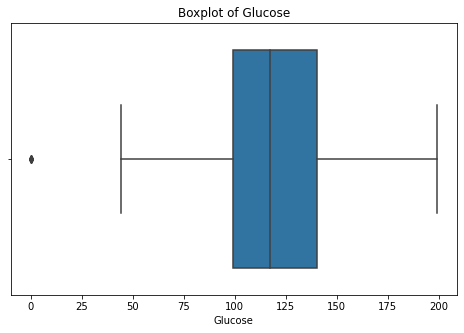

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x=data["Glucose"])
plt.title("Boxplot of Glucose")
plt.show()

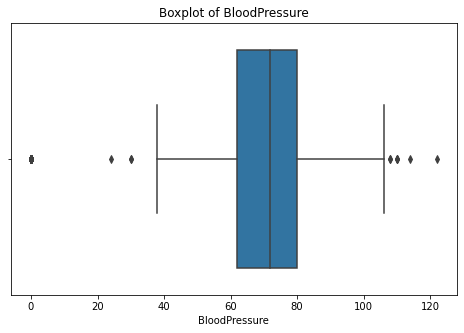

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x=data["BloodPressure"])
plt.title("Boxplot of BloodPressure")
plt.show()

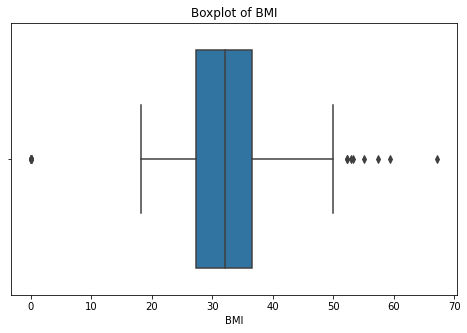

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(x=data["BMI"])
plt.title("Boxplot of BMI")
plt.show()

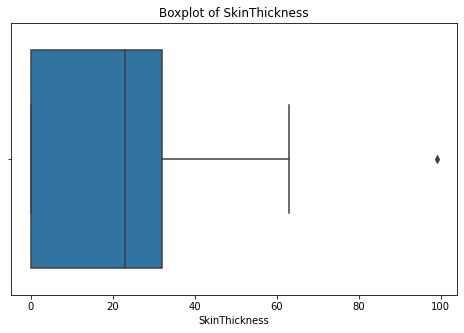

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x=data["SkinThickness"])
plt.title("Boxplot of SkinThickness")
plt.show()

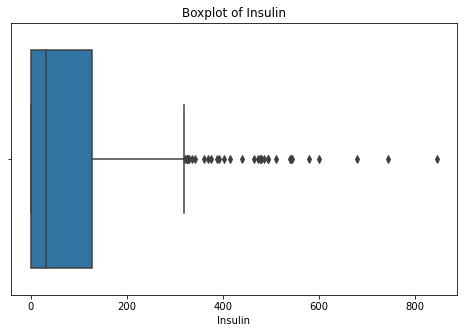

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(x=data["Insulin"])
plt.title("Boxplot of Insulin")
plt.show()

### Production-Level Checks Before Training

In [15]:
# nulls and duplicates:
display(data.isnull().sum())
display(data.duplicated().sum())
# display(data.dtypes)

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

0

In [19]:
(data["Glucose"] == 0).sum()
(data == 0).sum()
# there are fes cols which has values as zero which cannot realistically be zero.
# Zero usually means "missing measurement."

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

Why not simply leave the zeros?

Answer:

Because a glucose level of 0 is physiologically impossible for a living patient. In this dataset, zero is commonly used as a placeholder for missing values. Treating it as a real measurement would mislead the model.

In [30]:
# (data["Glucose"] == 0).sum()
def replace_value(col):
    data[col] =data[col].replace(0, np.nan)
    #Then impute.
    data[col].fillna(
        data[col].median(),
        inplace=True
    )

cols = ["Glucose","BloodPressure","BMI","SkinThickness","Insulin"]
for col in cols:
    replace_value(col)
(data["BloodPressure"] == 0).sum()

# did withe median :Median-->Outliers present. Most real datasets-->Median
#Repeat for the other physiological columns.

0

In [32]:
(data == 0).sum()

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [33]:
# Check for class balance:
data["Outcome"].value_counts()
#Classes are somewhat imbalanced.

0    500
1    268
Name: Outcome, dtype: int64

A common misconception is that "all machine learning algorithms require feature scaling." That's not true. A stronger answer is:

"Feature scaling depends on the algorithm. Distance-based and gradient-based algorithms generally benefit from scaling, while tree-based algorithms are largely unaffected because they make decisions based on feature order and split thresholds rather than absolute feature magnitudes."

In [37]:
X = data.drop("Outcome", axis=1)
display(X.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33


In [38]:
y = data["Outcome"]

In [39]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
scaler = StandardScaler()
model = LogisticRegression(max_iter=1000)
#
# model = LogisticRegression(class_weight="balanced")

In [44]:
X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [45]:
model.fit(X_train, y_train)

# Predict labels
predictions = model.predict(X_test)

# Predict probabilities
probabilities = model.predict_proba(X_test)[:, 1]

# Evaluation
print("Accuracy:", accuracy_score(y_test, predictions))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions))

print("ROC-AUC:", roc_auc_score(y_test, probabilities))

Accuracy: 0.7077922077922078

Confusion Matrix:
[[82 18]
 [27 27]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154

ROC-AUC: 0.812962962962963
